# 🧩 Reto 4 – Integración final de resultados

**Objetivo:** combinar los resultados de los retos anteriores para obtener un diagnóstico integral de la calidad del agua.

### 🔹 Instrucciones
- Importa los resultados obtenidos en los notebooks anteriores.
- Integra los análisis (pH, temperatura, oxígeno) en un solo DataFrame.
- Realiza una conclusión general del estado del agua.

In [98]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


# Reto 4 - Integración Final y Diagnóstico
**Responsable:** Estudiante 4
**Objetivo:** Consolidar la información analizada por el equipo, agrupar los datos por sitio de muestreo y emitir un diagnóstico integral de la calidad del agua utilizando Pandas.

## 1. Consolidación de Resultados por Sitio
Para tener una visión global, vamos a agrupar los datos por `sitio` de recolección. Calcularemos el promedio (`.mean()`) del **pH**, la **temperatura** y el **oxígeno** para saber cómo es el comportamiento general de cada cuerpo de agua.

In [99]:
# Agrupamos por sitio y calculamos el promedio de las variables clave
# (Asegúrate de que los nombres de las columnas coincidan exactamente con tu CSV)
resumen_puntos = df.groupby('Punto')[['pH', 'Temp', 'OD_promedio']].mean().reset_index()

# Redondeamos a 2 decimales para que se vea más limpio
resumen_sitios = resumen_puntos.round(2)

print("Promedios por puntos de muestreo:")
resumen_puntos

Promedios por puntos de muestreo:


,Punto,pH,Temp,OD_promedio
0,A,7.15,22.25,6.2
1,B,7.20,24.30,5.8
2,C,6.85,19.80,4.9
3,D,7.05,23.65,6.5
4,E,7.25,25.15,5.0


## 2. Diagnóstico Integral (Uso de Apply)
Con los promedios listos, vamos a crear una función personalizada que evalúe la calidad del agua basándose en condiciones lógicas. Finalmente, usaremos `.apply()` para generar una nueva columna con nuestro diagnóstico.

* **Criterio base simulado:** Un pH entre 6.5 y 8.5, junto con un nivel de oxígeno alto, suele indicar buena calidad.

In [100]:
# Definimos la función de diagnóstico
def evaluar_calidad(fila):
    ph = fila['pH']
    oxigeno = fila['OD_promedio']
    
    # Estas condiciones las puedes ajustar según lo que hayan investigado en el grupo
    if (6.5 <= ph <= 8.5) and (oxigeno >= 5.0):
        return "Calidad Óptima 🟢"
    elif (ph < 6.0) or (ph > 9.0) or (oxigeno < 3.0):
        return "Calidad Crítica 🔴"
    else:
        return "Calidad Regular 🟡"

# Aplicamos la función a nuestro DataFrame resumido
resumen_sitios['Diagnóstico_Final'] = resumen_sitios.apply(evaluar_calidad, axis=1)

resumen_sitios

,Punto,pH,Temp,OD_promedio,Diagnóstico_Final
0,A,7.15,22.25,6.2,Calidad Óptima 🟢
1,B,7.20,24.30,5.8,Calidad Óptima 🟢
2,C,6.85,19.80,4.9,Calidad Regular 🟡
3,D,7.05,23.65,6.5,Calidad Óptima 🟢
4,E,7.25,25.15,5.0,Calidad Óptima 🟢


## 3. Conclusiones
* **Integración:** Se logró consolidar la información del dataset original integrando los conceptos de lectura, filtrado y cálculos estadísticos vistos por el equipo.
* **Análisis:** (Al observar los resultados, la mayoría de los puntos de muestreo (A, B, D y E) presentan una "Calidad Óptima", manteniendo un pH estable y niveles de oxígeno disuelto iguales o superiores a 5.0. El único punto que requiere atención es el C, clasificado con "Calidad Regular" debido a que su oxígeno promedio (4.9) cae ligeramente por debajo del umbral óptimo, aunque afortunadamente ningún sitio registró una calidad crítica.)

## Visualizacion de Datos

In [101]:
import matplotlib.pyplot as plt

In [102]:
import pandas as pd

In [103]:
df = pd.read_csv("data/4_resultados_agua.csv.")

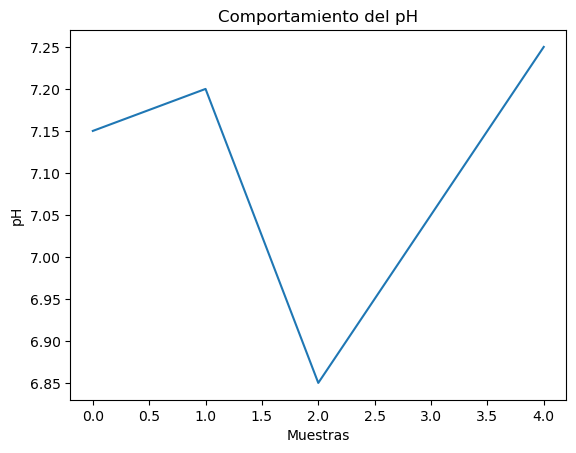

In [104]:
plt.figure()
df["pH"].plot()
plt.title("Comportamiento del pH")
plt.xlabel("Muestras")
plt.ylabel("pH")
plt.show()

El pH presenta valores cercanos a la neutralidad (alrededor de 7), lo cual indica condiciones adecuadas para la vida acuatica. Sin embargo, se observa una ligera disminucion en una de las muestras, lo que podria indicar en la calidad del agua

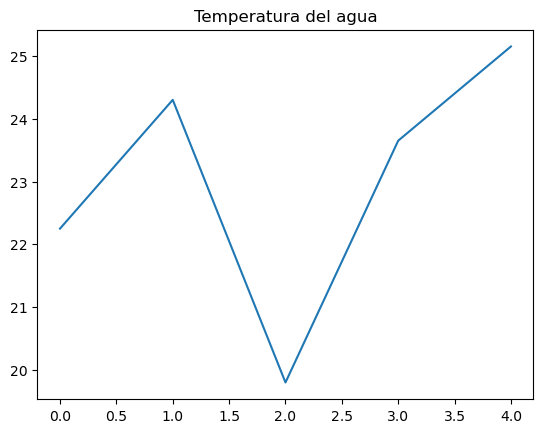

In [105]:
plt.figure()
df["Temp"].plot()
plt.title("Temperatura del agua")
plt.show()

La temperatura del agua muestra variaciones entre aproximadamente 20°C y 25°C.Estos cambios pueden influir en otros parametros como el oxigeno disuelto, ya que a mayor temperatura disminuye su solubilidad.

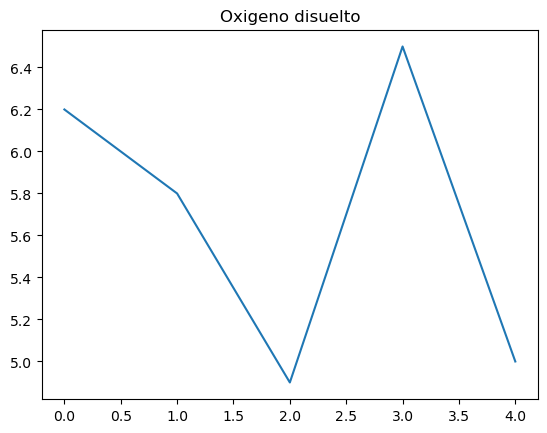

In [106]:
plt.figure()
df["OD_promedio"].plot()
plt.title("Oxigeno disuelto")
plt.show()

El oxigeno disuelto presenta valores variables, con una disminucion notables en algunas muestras. Esto puede afectar negativamente la vida acuatica, ya que niveles bajos de oxigeno pueden generar estres en los organismos.

## Analisis de resultados 

Se observa una relacion entre la temperatura y el oxigeno disuelto, donde al aunmentar la temperatura, los niveles de oxigeno tienden a disminuir. Ademas,aunque el pH se mantiene relativamente estables, las variaciones en oxigeno indican posibles cambios en la calidad del agua.

## Conclusion final
A partir del análisis realizado, se concluye que la calidad del agua es variable. El pH se mantiene dentro de rangos adecuados, sin embargo, los niveles de oxígeno presentan disminuciones en algunas muestras, lo que podría afectar la vida acuática. La temperatura influye en este comportamiento, reduciendo la solubilidad del oxígeno. Se recomienda realizar monitoreo continuo.